In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from sympy import *
from sympy.utilities.lambdify import lambdify


In [2]:
def f(x):
    return x**2

print(f(3))

9


In [6]:
def dfdx(x):
    return 2*x

In [4]:
x_array = np.array([1, 2, 3])

print(f(x_array))

[1 4 9]


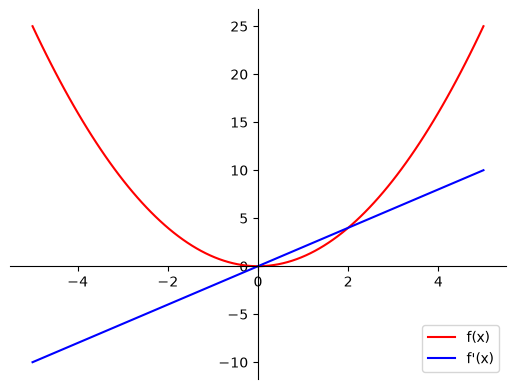

In [9]:
%matplotlib inline

def plot_f1_and_f2(f1, f2=None, x_min=-5, x_max=5, label1="f(x)", label2="f'(x)"):
    x = np.linspace(x_min, x_max,100)

    # Setting the axes at the centre.
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    ax.spines['left'].set_position('center')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    plt.plot(x, f1(x), 'r', label=label1)
    if not f2 is None:
        # If f2 is an array, it is passed as it is to be plotted as unlinked points.
        # If f2 is a function, f2(x) needs to be passed to plot it.        
        if isinstance(f2, np.ndarray):
            plt.plot(x, f2, 'bo', markersize=3, label=label2,)
        else:
            plt.plot(x, f2(x), 'b', label=label2)
    plt.legend()

    plt.show()
    
plot_f1_and_f2(f, dfdx)

In [13]:
one = math.sqrt(18)
two = sqrt(18)

print(f"Math: {one}")
print(f"Sym: {two}")

Math: 4.242640687119285
Sym: 3*sqrt(2)


In [14]:
# Vars need to be defined as symbols
x, y = symbols('x y')
expression = 2*(x**2) - x*y

print(expression)

2*x**2 - x*y


In [16]:
expr_manip = x * (expression + x * y + x**3)

print(expr_manip)
print(expand(expr_manip))

x*(x**3 + 2*x**2)
x**4 + 2*x**3


In [17]:
print(expression.evalf(subs={x:-1, y:2}))

4.00000000000000


In [23]:
f_symb = x ** 2

try:
    f_symb(x_array)
except TypeError as err:
    print(err)

f_symb_numpy = lambdify(x, f_symb, 'numpy')

print(f_symb_numpy(x_array))

'Pow' object is not callable
[1 4 9]


In [24]:
# Finding derivative
print(diff(x**3, x))

3*x**2


In [27]:
dfdx_symb = diff(f_symb, x)
dfdx_symb_numpy = lambdify(x, dfdx_symb, 'numpy')

print("x: \n", x_array)
print("f'(x) = 2x: \n", dfdx_symb_numpy(x_array))

x: 
 [1 2 3]
f'(x) = 2x: 
 [2 4 6]


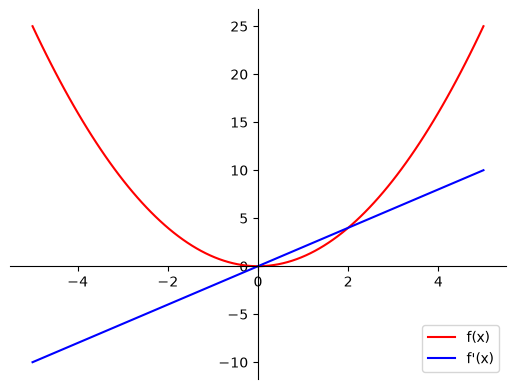

In [28]:
plot_f1_and_f2(f_symb_numpy, dfdx_symb_numpy)

In [29]:
x_array_2 = np.linspace(-5, 5, 100)
print(x_array_2)

[-5.         -4.8989899  -4.7979798  -4.6969697  -4.5959596  -4.49494949
 -4.39393939 -4.29292929 -4.19191919 -4.09090909 -3.98989899 -3.88888889
 -3.78787879 -3.68686869 -3.58585859 -3.48484848 -3.38383838 -3.28282828
 -3.18181818 -3.08080808 -2.97979798 -2.87878788 -2.77777778 -2.67676768
 -2.57575758 -2.47474747 -2.37373737 -2.27272727 -2.17171717 -2.07070707
 -1.96969697 -1.86868687 -1.76767677 -1.66666667 -1.56565657 -1.46464646
 -1.36363636 -1.26262626 -1.16161616 -1.06060606 -0.95959596 -0.85858586
 -0.75757576 -0.65656566 -0.55555556 -0.45454545 -0.35353535 -0.25252525
 -0.15151515 -0.05050505  0.05050505  0.15151515  0.25252525  0.35353535
  0.45454545  0.55555556  0.65656566  0.75757576  0.85858586  0.95959596
  1.06060606  1.16161616  1.26262626  1.36363636  1.46464646  1.56565657
  1.66666667  1.76767677  1.86868687  1.96969697  2.07070707  2.17171717
  2.27272727  2.37373737  2.47474747  2.57575758  2.67676768  2.77777778
  2.87878788  2.97979798  3.08080808  3.18181818  3

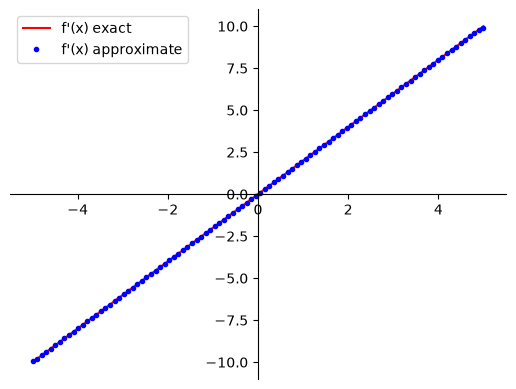

In [31]:
dfdx_diff = np.gradient(f(x_array_2), x_array_2)
dfdx_composed = diff(exp(-2*x) + 3*sin(3*x), x)
plot_f1_and_f2(dfdx_symb_numpy, dfdx_diff, label1="f'(x) exact", label2="f'(x) approximate")

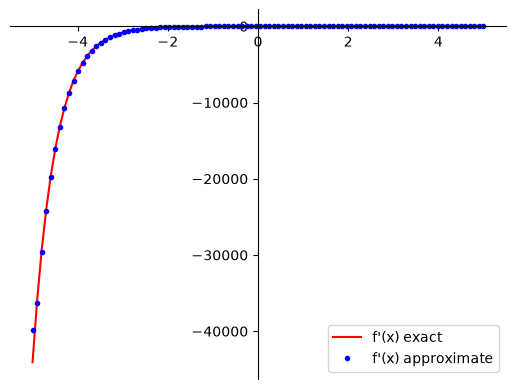

In [32]:
def f_composed(x):
    return np.exp(-2*x) + 3*np.sin(3*x)

plot_f1_and_f2(lambdify(x, dfdx_composed, 'numpy'), np.gradient(f_composed(x_array_2), x_array_2),
              label1="f'(x) exact", label2="f'(x) approximate")

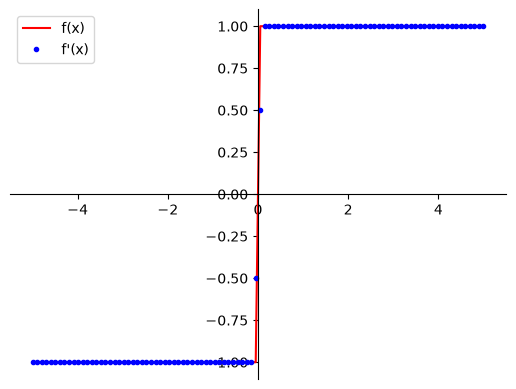

In [33]:
def dfdx_abs(x):
    if x > 0:
        return 1
    else:
        if x < 0:
            return -1
        else:
            return None

plot_f1_and_f2(np.vectorize(dfdx_abs), np.gradient(abs(x_array_2), x_array_2))

You can see that the results near the "jump" are $0.5$ and $-0.5$, while they should be $1$ and $-1$. These cases can give significant errors in the computations.

But the biggest problem with the numerical differentiation is slow speed. It requires function evalutation every time.  In machine learning models there are hundreds of parameters and there are hundreds of derivatives to be calculated, performing full function evaluation every time slows down the computation process. You will see the example of it below.